# **TITANIC SURVIVAL PREDICTION** 

## **Data Load**

In [1]:
# IMPORT LIBRARIES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
# LOAD DATA

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print(f"Shape : {df.shape}")
print(f"\nSample data:")
df.head()

Shape : (891, 12)

Sample data:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## **EDA** 

In [3]:
# Overview

print("=" * 40)
print("DATASET OVERVIEW")
print("=" * 40)
print(f"Shape    : {df.shape}")
print(f"Columns  : {list(df.columns)}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

DATASET OVERVIEW
Shape    : (891, 12)
Columns  : ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Duplicate Rows: 0


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
# Target Distribution

print("=" * 40)
print("TARGET DISTRIBUTION (Survived)")
print("=" * 40)
survival_rate = df["Survived"].value_counts(normalize=True) * 100
print(f"Not Survived (0) : {survival_rate[0]:.1f}%")
print(f"Survived (1) : {survival_rate[1]:.1f}%")

TARGET DISTRIBUTION (Survived)
Not Survived (0) : 61.6%
Survived (1) : 38.4%


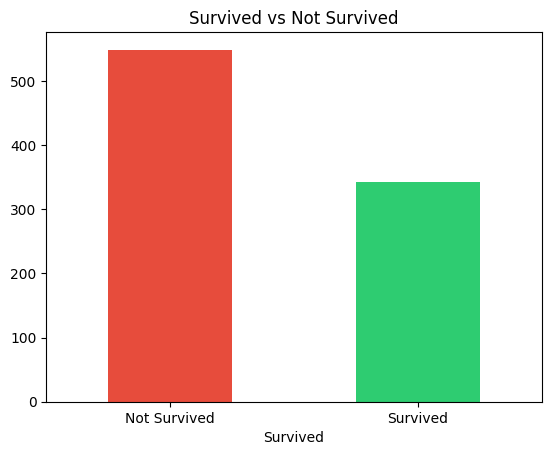

In [6]:
df["Survived"].value_counts().plot(kind="bar", color=["#e74c3c", "#2ecc71"])
plt.title("Survived vs Not Survived")
plt.xticks([0, 1], ["Not Survived", "Survived"], rotation=0)
plt.show()

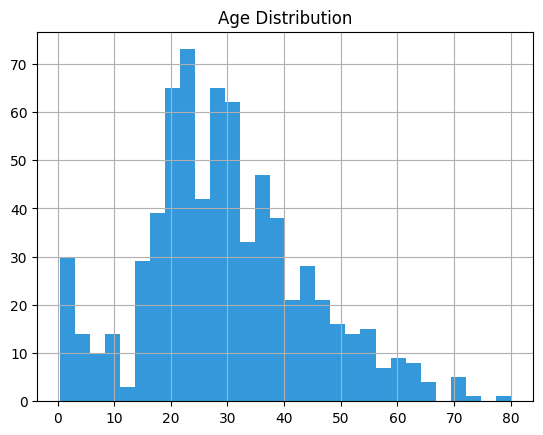

In [7]:
# Age Distribution

df["Age"].hist(bins=30, color="#3498db")
plt.title("Age Distribution")
plt.show()

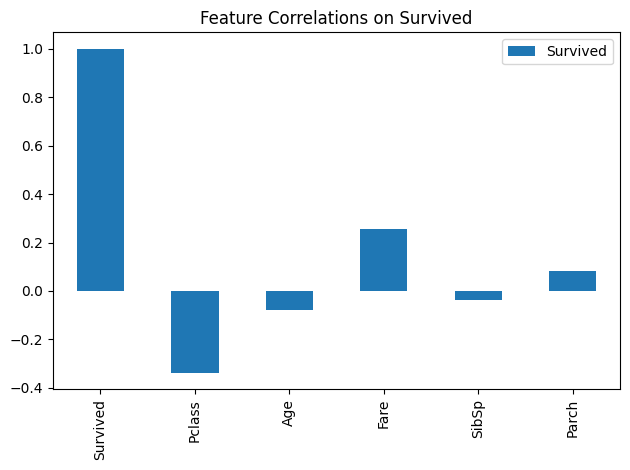

In [8]:
# Correlations

df[["Survived","Pclass","Age","Fare","SibSp","Parch"]].corr()[["Survived"]].plot(kind="bar")
plt.title("Feature Correlations on Survived")
plt.tight_layout()
plt.show()

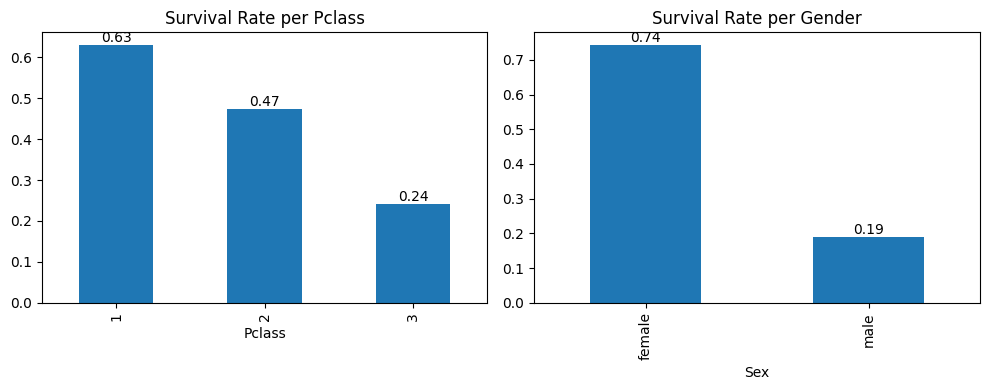

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df.groupby("Pclass")["Survived"].mean().plot(kind="bar", ax=axes[0])
axes[0].set_title("Survival Rate per Pclass")
for p in axes[0].patches:                         
    axes[0].annotate(f"{p.get_height():.2f}",      
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center", va="bottom")

df.groupby("Sex")["Survived"].mean().plot(kind="bar", ax=axes[1])
axes[1].set_title("Survival Rate per Gender")
for p in axes[1].patches:                          
    axes[1].annotate(f"{p.get_height():.2f}",      
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center", va="bottom")

plt.tight_layout()
plt.show()

## **Preprocessing**

In [10]:
# Drop Unnecessary Columns

df = df.drop(columns=["Name", "Ticket", "PassengerId", "Cabin"])
print(f"Shape after drop : {df.shape}")

Shape after drop : (891, 8)


In [11]:
# Handle Missing Values

df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
print("Missing values after handling:")
print(df.isnull().sum())

Missing values after handling:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [12]:
# Encode Categorical Columns
from sklearn.preprocessing import LabelEncoder, StandardScaler

# female=0, male=1
df["Sex"] = LabelEncoder().fit_transform(df["Sex"])

# C=0, Q=1, S=1
df["Embarked"] = LabelEncoder().fit_transform(df["Embarked"])
print("\nEncoded data samples:")
df.head()


Encoded data samples:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


## **Modeling** 

In [13]:
# Feature & Target Split
from sklearn.model_selection import train_test_split

x = df.drop(columns=["Survived"])
y = df["Survived"]

print(f"Features : {list(x.columns)}")
print(f"X Shape : {x.shape}")
print(f"y Shape : {y.shape}")

Features : ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X Shape : (891, 7)
y Shape : (891,)


In [14]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

print(f"X_train : {X_train.shape}")
print(f"X_test : {X_test.shape}")

X_train : (712, 7)
X_test : (179, 7)


In [15]:
# Numerical Features Scaling

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
# Three Models Training
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=10000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

}

for names, model in models.items():
    model.fit(X_train, y_train)
    print(f"{names} -> trained")

Logistic Regression -> trained
Decision Tree -> trained
Random Forest -> trained


## **Evaluation**

In [17]:
# Accuracy Comparison
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix)

print("=" * 45)
print(f"{'MODEL':<25} {'TRAIN':>8} {'TEST':>8}")
print("=" * 45)

for names, model in models.items():
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    print(f"{names:<25} {train_acc:>8.4f} {test_acc:>8.4f}")

print("=" * 45)

MODEL                        TRAIN     TEST
Logistic Regression         0.8006   0.8045
Decision Tree               0.8497   0.7989
Random Forest               0.8567   0.8156


In [18]:
# Classification Report - Best Model

best_model = models["Random Forest"]
y_pred = best_model.predict(X_test)

print("\nClassification Report - Random Forest:")
print(classification_report(y_test, y_pred,
                            target_names=["Not Survived", "Survived"]))


Classification Report - Random Forest:
              precision    recall  f1-score   support

Not Survived       0.81      0.90      0.85       105
    Survived       0.84      0.69      0.76        74

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.80       179
weighted avg       0.82      0.82      0.81       179



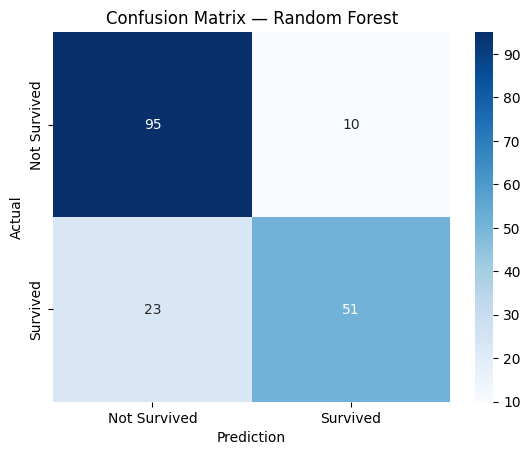

In [19]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Survived", "Survived"],
            yticklabels=["Not Survived", "Survived"])
plt.title("Confusion Matrix — Random Forest")
plt.ylabel("Actual")
plt.xlabel("Prediction")
plt.show()

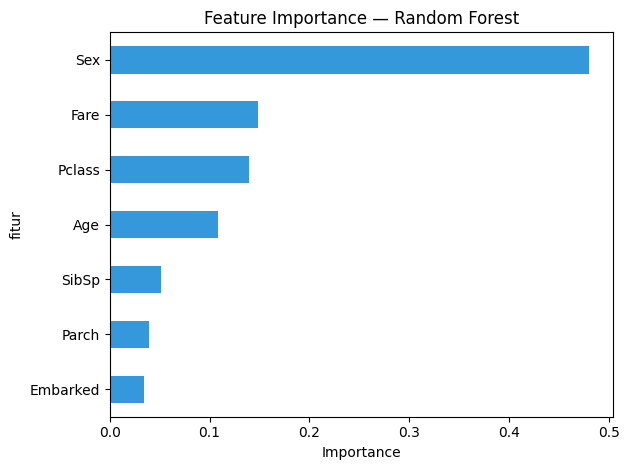

In [20]:
# Feature Importance

importance = pd.DataFrame({
    "fitur"     : x.columns,
    "importance": models["Random Forest"].feature_importances_
}).sort_values("importance", ascending=True)

importance.plot(kind="barh", x="fitur", y="importance",
                legend=False, color="#3498db")
plt.title("Feature Importance — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## **Conclusion**

Key Insights from EDA:
- Female passengers had significantly higher survival rate (74% vs 19%)
- First class passengers survived more than other classes (63%)
- Children under 16 were prioritized during evacuation (59%)

Preprocessing Steps:
- Dropped irrelevant columns (Name, Ticket, PassengerId, Cabin)
- Filled missing Age with median, Embarked with mode
- Label Encoding applied to Sex and Embarked
- StandardScaler applied to normalize numeric features

Best Model : Random Forest

Model Performance:
Classification Report - Random Forest:

| Class / Metric | Recall | Precision | F1-Score | Support |
|---|---|---|---|---|
| Not Survived | 0,90 | 0,81 | 0,85 | 105 |
| Survived | 0,69 | 0,80 | 0,76 | 74 |
| Accuracy | - | - | 0,82 | 179 |
| Macro Avg | 0,80 | 0,82 | 0,80 | 179 |
| Weighted Avg | 0,82 | 0,82 | 0,81 | 179 |